In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from astropy.io import fits
from sklearn.model_selection import train_test_split

I0000 00:00:1782294481.650681   15992 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782294481.681445   15992 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782294482.668699   15992 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Check if TensorFlow detects any GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Success! TensorFlow detected {len(gpus)} GPU(s): {gpus}")

    # Best Practice: Enable Memory Growth
    # This prevents TensorFlow from instantly reserving all your GPU VRAM,
    # which can crash your system or prevent other apps from running.
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("Warning: No GPU detected. TensorFlow will fall back to the CPU.")

E0000 00:00:1782294486.154514   15992 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================

def load_and_preprocess_ifu_data(data_dir, csv_path, filename_col, label_col):
    """
    Reads FITS files and labels, processes the IFU maps, and prepares them for TF.
    """
    # Load the CSV containing labels (0, 1, 2, 3)
    df = pd.read_csv(csv_path)

    images = []
    labels = []

    for index, row in df.iterrows():
        filename = row[filename_col]
        label = row[label_col]
        if label == -1:
            continue
        filepath = os.path.join(data_dir, filename)

        # Read the zeroth HDU
        with fits.open(filepath) as hdul:
            data = hdul[0].data  # Expected shape: (3, 69, 69)

        # Process each channel (flux, velocity, dispersion) independently
        for i in range(3):
            channel_data = data[i, :, :]

            # 1. Handle NaNs: Replace with the channel's mean
            mean_val = np.nanmean(channel_data)
            if np.isnan(mean_val):
                mean_val = 0.0  # Fallback if the entire channel is NaN
            channel_data[np.isnan(channel_data)] = mean_val

            # 2. Scale data to range [-1, 1]
            c_min = np.min(channel_data)
            c_max = np.max(channel_data)
            if c_max > c_min:
                # Min-Max scaling to [-1, 1]
                channel_data = 2 * ((channel_data - c_min) / (c_max - c_min)) - 1
            else:
                channel_data = 0.0 # Fallback if channel has zero variance

            data[i, :, :] = channel_data

        # Transpose from (Channels, Height, Width) to (Height, Width, Channels)
        data = np.transpose(data, (1, 2, 0)) # New shape: (69, 69, 3)

        images.append(data)
        labels.append(label)

    # Convert lists to NumPy arrays
    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)

    return X, y

In [4]:

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================

def build_ifu_model(input_shape=(69, 69, 3), num_classes=4):
    """
    Builds a CNN using DepthwiseConv2D for initial independent channel processing.
    """
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),

        # DEPTHWISE CONVOLUTION
        # Treats Flux, Velocity, and Dispersion independently.
        # depth_multiplier=8 means it creates 8 feature maps *per* input channel (24 total)
        tf.keras.layers.DepthwiseConv2D(
            kernel_size=(3, 3),
            depth_multiplier=8,
            activation='relu',
            padding='same'
        ),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # STANDARD CONVOLUTION (Mixing layer)
        # This standard Conv2D layer will now mix the features learned from
        # the independent flux, velocity, and dispersion depthwise filters.
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Further feature extraction
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Flatten and Classify
        tf.keras.layers.GlobalAveragePooling2D(), # Better against overfitting than Flatten()
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3), # Regularization

        # 4 Classes -> Softmax output
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    # Compile the model
    # SparseCategoricalCrossentropy is used because labels are integers (0, 1, 2, 3)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:

# ==========================================
# 3. EXECUTION PIPELINE
# ==========================================


# --- Configuration Variables ---
# UPDATE THESE PATHS AND COLUMN NAMES TO MATCH YOUR SETUP
DATA_DIRECTORY = "./VELOCITY_VDISP_FLUX MAPS"
CSV_FILE_PATH = "./files_list_and_axis.csv"
FILENAME_COLUMN_NAME = "filename"
LABEL_COLUMN_NAME = "type"

In [6]:

print("Loading and preprocessing data...")
X, y = load_and_preprocess_ifu_data(
    data_dir=DATA_DIRECTORY,
    csv_path=CSV_FILE_PATH,
    filename_col=FILENAME_COLUMN_NAME,
    label_col=LABEL_COLUMN_NAME
)


Loading and preprocessing data...


In [7]:

print(f"Data loaded! Shape of X: {X.shape}, Shape of y: {y.shape}")

Data loaded! Shape of X: (8978, 69, 69, 3), Shape of y: (8978,)


In [8]:
print('spheres', np.sum(y==0))
print('oblate', np.sum(y==1))
print('prolate', np.sum(y==2))
print('triaxial', np.sum(y==3))

spheres 58
oblate 7431
prolate 90
triaxial 1399


In [9]:


# Split into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:

print("Building model...")
model2 = build_ifu_model(input_shape=(69, 69, 3), num_classes=4)
model2.summary()

Building model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 69, 69, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 69, 69, 24)     │           240 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 34, 34, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,100 (117.58 KB)

 Trainable params: 30,100 (117.58 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:

print("Configuring Early Stopping...")
# Define the EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # The metric to watch
    patience=8,                # How many epochs to wait for improvement before stopping
    restore_best_weights=True, # CRITICAL: Revert to the weights of the best epoch
    verbose=1                  # Prints a message when stopping is triggered
)

Configuring Early Stopping...


In [12]:

print("Starting training with Early Stopping...")
# Train the model, passing the callback in a list
history = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,                 # You can set this high now; early stopping will catch it
    batch_size=128,
    callbacks=[early_stopping] # <--- Add the callback here
)

Starting training with Early Stopping...
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.7985 - loss: 0.6807 - val_accuracy: 0.8235 - val_loss: 0.5480
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.8283 - loss: 0.5501 - val_accuracy: 0.8235 - val_loss: 0.5394
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.8286 - loss: 0.5307 - val_accuracy: 0.8235 - val_loss: 0.5389
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.8287 - loss: 0.5130 - val_accuracy: 0.8235 - val_loss: 0.5237
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.8292 - loss: 0.5043 - val_accuracy: 0.8235 - val_loss: 0.5180
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.8287 - loss: 0.4953 - val_accuracy: 0.8179 - val_loss: 0.5157
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.8304 - loss: 0.4963 - val_accuracy: 0.8235 - val_loss: 0.5140
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - a

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [14]:

# ==========================================
# 4. PLOTTING TRAINING CURVES
# ==========================================

def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss curves.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [15]:

# ==========================================
# 5. DETAILED EVALUATION
# ==========================================

def evaluate_model_performance(model, X_val, y_val, class_names=None):
    """
    Evaluates the model on validation data and plots a confusion matrix.
    """
    print("\n--- Final Model Evaluation ---")
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Loss: {loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Get predictions
    # model.predict returns an array of probabilities for the 4 classes
    y_pred_probs = model.predict(X_val)
    # Convert probabilities to actual class labels (0, 1, 2, 3)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Print Classification Report (Precision, Recall, F1-Score per class)
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=class_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))

    # Using seaborn for a heatmap representation
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names if class_names else [0, 1, 2, 3],
                yticklabels=class_names if class_names else [0, 1, 2, 3])

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

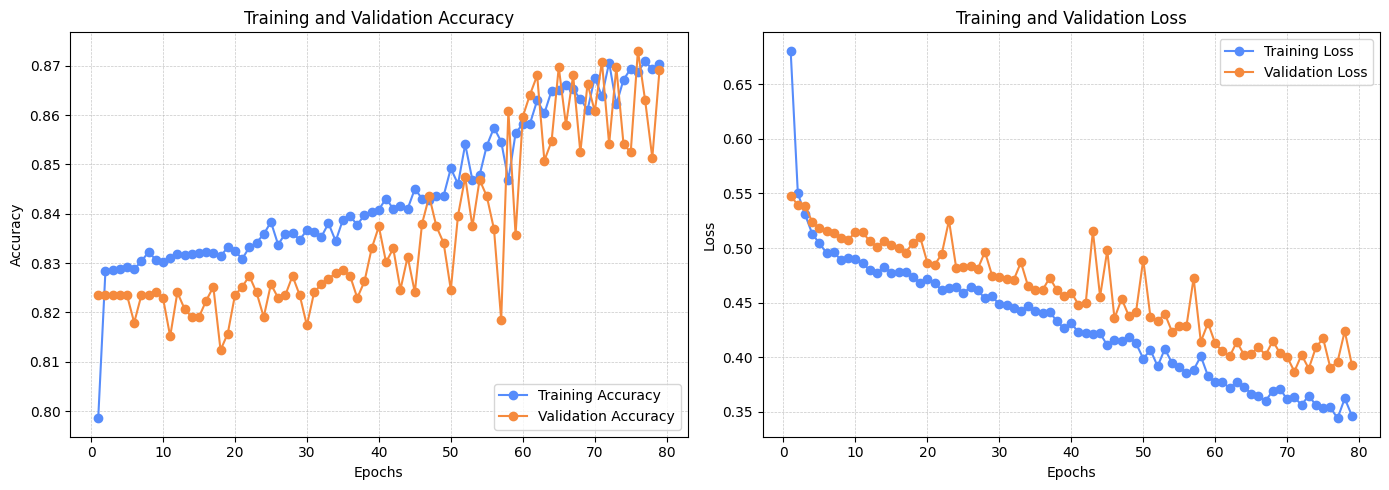

In [16]:

# ==========================================
# ADD THIS TO YOUR EXECUTION PIPELINE
# ==========================================
# (Run this right after 'history = model.fit(...)')

# Plot the curves
plot_training_history(history)


--- Final Model Evaluation ---
Validation Loss: 0.3869
Validation Accuracy: 0.8708
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Classification Report:
              precision    recall  f1-score   support

    Sperical       0.00      0.00      0.00        13
      Oblate       0.88      0.99      0.93      1479
     Prolate       0.00      0.00      0.00        22
    Triaxial       0.79      0.37      0.51       282

    accuracy                           0.87      1796
   macro avg       0.42      0.34      0.36      1796
weighted avg       0.85      0.87      0.84      1796



/home/astrolander/.generalvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/astrolander/.generalvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/astrolander/.generalvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

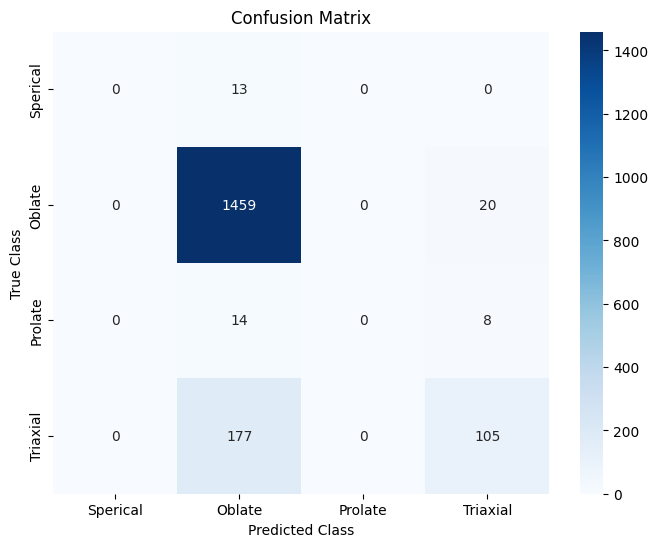

In [18]:

# Evaluate and show confusion matrix
# (e.g., ['Spiral', 'Elliptical', 'Merger', 'Irregular'])
evaluate_model_performance(model2, X_val, y_val, class_names=['Sperical', 'Oblate', 'Prolate', 'Triaxial'])